## Obserwacje z zad 1

W EDA korzystałem bardzo dużo z macierzy korelacji i pozbyłem się cech które mają bardzo małą korelacje z cechą survived i dodatkowo utworzyłem cechy które mają w miare rozsądny poziom tej korelacji

Bezużyteczne były cechy takie jak:
- Name

Cechy które wymagały zmiany:
- Cabin
- Embarked
- Ticket
- Parch
- SibSp
- Age

Cechy które były przydatne same z siebie:
- Fare
- Pclass
- Survived
- Sex

Utworzyłem takie klasy jak:
- HasCabin
- IsAlone(uwzględniające FamilySize ale też TicketSize)
- HasAge
- AgeCat

Wiemy tez ze nie wszystkie Cechy mają rozkład Normalny co znaczy że danych nie możemy ustandaryzowac(Do skalowania użyje RobustScalera zeby zabezpieczyć się przed Skrajnymi wartosciami)

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
path = Path.cwd() / "titanic_cleaned.csv"
titanic_cleaned = pd.read_csv(path, index_col='PassengerId')

Zacznijmy od podstawowych czynności:
- Oddzielenie label od reszty cech
- wyskalowanie danych
- podział na zbiór testowy, treningowy oraz walidacyjny


In [65]:
X = titanic_cleaned.drop("Survived", axis=1)
y = titanic_cleaned["Survived"]
labels = X.columns

transformer = sk.preprocessing.RobustScaler()


X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, train_size=.8, shuffle=True)
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)


wytrenujmy sobie dummy classifiera

In [66]:
model_dum = DummyClassifier(strategy = 'uniform')
model_dum.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'uniform'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.61,0.39]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,9
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


Napiszmy sobie funkcje Benchmark która będzie sprawdzała jakość danego modelu

Jako kluczowe metryki oceniania wybrałem:
- F1 score (Mierzy średnią Precyzji (Precision) i Czułości (Recall). Daje rzetelną ocenę jakości klasyfikacji dla grupy Survived na niezbalansowanym zbiorze)
- ROC-AUC (Niezależnie od wybranego progu odcięcia, pozwala obiektywnie ocenić jakość rankingowania prawdopodobieństw)
- Confusion Matrix(poglądowo)



In [67]:
def Benchmark(model, ref=False, X_test=X_test, y_test=y_test):
    y_pred = model.predict(X_test)

    # Obsługa głównego modelu
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_model = roc_auc_score(y_test, y_proba)
        plt.plot(*roc_curve(y_test, y_proba)[:2], label="Model")
    else:
        auc_model = "Brak proba"
        print("Błąd: Główny model nie obsługuje predict_proba (np. SVC bez probability=True).")

    if ref:
        y_pred_ref = ref.predict(X_test)

        # Obsługa modelu referencyjnego
        if hasattr(ref, "predict_proba"):
            y_proba_ref = ref.predict_proba(X_test)[:, 1]
            auc_ref = roc_auc_score(y_test, y_proba_ref)
            plt.plot(*roc_curve(y_test, y_proba_ref)[:2], label="Ref", linestyle="--")
        else:
            auc_ref = "Brak proba"
            print("Błąd: Model referencyjny nie obsługuje predict_proba.")

        print("Model - F1:", f1_score(y_test, y_pred), "AUC:", auc_model)
        print("Ref - F1:", f1_score(y_test, y_pred_ref), "AUC:", auc_ref)
        print("Model CM:\n", confusion_matrix(y_test, y_pred))
        print("Ref CM:\n", confusion_matrix(y_test, y_pred_ref))

    else:
        print("F1:", f1_score(y_test, y_pred), "AUC:", auc_model)
        print(confusion_matrix(y_test, y_pred))


    if hasattr(model, "predict_proba") or (ref and hasattr(ref, "predict_proba")):
        plt.legend()
        plt.show()

F1: 0.46258503401360546 AUC: 0.5
[[65 52]
 [27 34]]


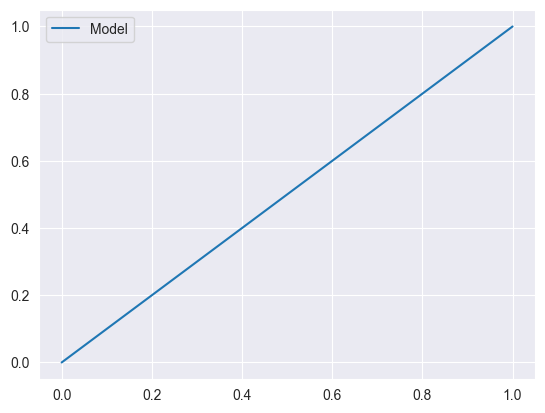

In [68]:
Benchmark(model_dum)

no i widzimy za pomocą funkcji benchmark że dummy_classifier nie rózni nam sie od losowego wybierania a nawet wydaje sie troche gorsze(zależy jak polosuje)

jako pierwszy model wybierzemy sobie random forest

Model - F1: 0.7413793103448276 AUC: 0.8479753397786186
Ref - F1: 0.2962962962962963 AUC: 0.5
Model CM:
 [[105  12]
 [ 18  43]]
Ref CM:
 [[63 54]
 [41 20]]


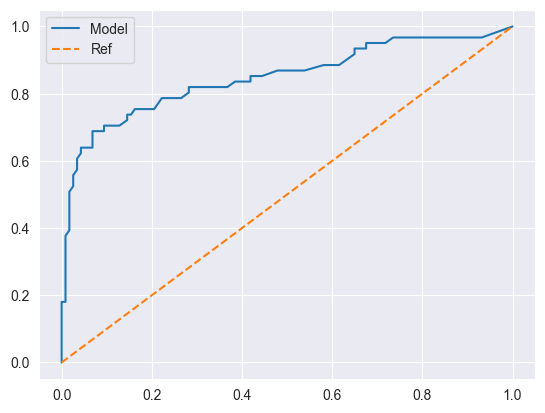

In [69]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
Benchmark(model,model_dum)

Jak widzimy Jest dużo lepszy niż model dummy, także nie ma co uciekać :)

Jako następny model Wybieram KNN z odległością cosinusową(cosinusowa bo zależy nam na wychwytywaniu poszczególnych zależności a nie na odległości w rozumieniu euklidesowym)

Model - F1: 0.7192982456140351 AUC: 0.867241137732941
Ref - F1: 0.38926174496644295 AUC: 0.5
Model CM:
 [[105  12]
 [ 20  41]]
Ref CM:
 [[58 59]
 [32 29]]


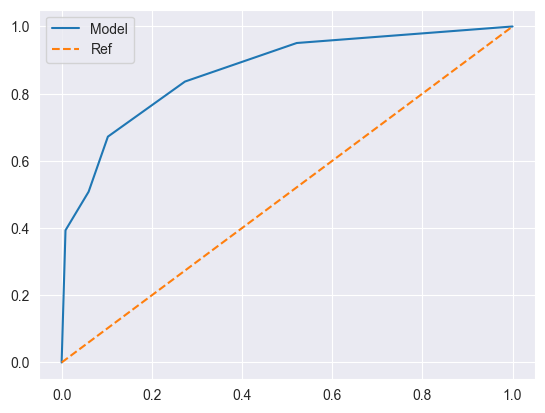

In [70]:
from sklearn.neighbors import KNeighborsClassifier
# KNN z metryką cosine similarity
knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn.fit(X_train, y_train)
Benchmark(knn,model_dum)

No i jak widzimy faktycznie też jest lepszy od dummy

# Porównanie KNN z RandomForest

KNN jako model główny i RandomForest jako referencyjny

Model - F1: 0.7192982456140351 AUC: 0.867241137732941
Ref - F1: 0.7413793103448276 AUC: 0.8479753397786186
Model CM:
 [[105  12]
 [ 20  41]]
Ref CM:
 [[105  12]
 [ 18  43]]


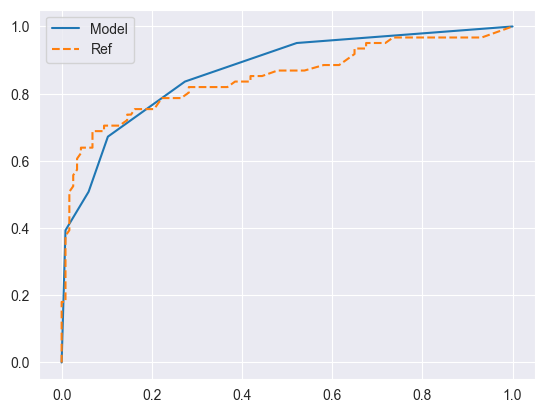

In [71]:
Benchmark(knn,model)

Widzimy że RandomForest radzi sobie troche lepiej

Natomiast wydaje mi się że dałoby się uzyskać troche lepszy wynik Sprawdźmy jak rasdzi sobie SVM

SVC(bazowy)

KNN(referencyyjny)

Błąd: Główny model nie obsługuje predict_proba (np. SVC bez probability=True).
Model - F1: 0.6890756302521008 AUC: Brak proba
Ref - F1: 0.7413793103448276 AUC: 0.8479753397786186
Model CM:
 [[100  17]
 [ 20  41]]
Ref CM:
 [[105  12]
 [ 18  43]]


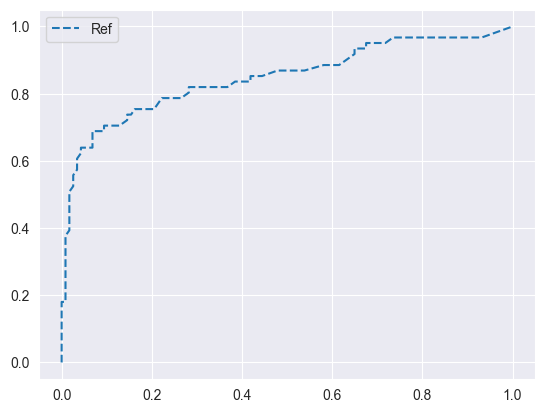

In [72]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')  # liniowe SVM
svc.fit(X_train, y_train)
Benchmark(svc,model)

Dobra no widzimy że dla SVC nie mamy ROC-AUC a to dla tego ze svc nie ma parametru proba, wynika to z działania algorytmu które wyznacza granice wśród cech którą albo się przekracza albo nie, więc nie ma opcji ustawiania tresholdu.

Porównajmy sobie te modele przy cross validation żeby uzyskać pewniejsze wyniki.



In [73]:
from sklearn.model_selection import cross_val_predict

def Benchmark_CV(model, ref=False, X=X, y=y, cv=5):
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    plt.plot(*roc_curve(y, y_proba)[:2], label="Model")

    if ref:
        y_proba_ref = cross_val_predict(ref, X, y, cv=cv, method='predict_proba')[:, 1]
        y_pred_ref = (y_proba_ref >= 0.5).astype(int)
        print("Model - F1:", f1_score(y, y_pred), "AUC:", roc_auc_score(y, y_proba))
        print("Ref - F1:", f1_score(y, y_pred_ref), "AUC:", roc_auc_score(y, y_proba_ref))
        print("Model CM:\n", confusion_matrix(y, y_pred))
        print("Ref CM:\n", confusion_matrix(y, y_pred_ref))

        plt.plot(*roc_curve(y, y_proba_ref)[:2], label="Ref", linestyle="--")
    else:
        print("F1:", f1_score(y, y_pred), "AUC:", roc_auc_score(y, y_proba))
        print(confusion_matrix(y, y_pred))

    plt.legend()
    plt.show()

teraz sprawdzmy porownanie KNN z Random forest

Model - F1: 0.6024464831804281 AUC: 0.7385353048323153
Ref - F1: 0.7177914110429447 AUC: 0.8447712418300652
Model CM:
 [[432 117]
 [143 197]]
Ref CM:
 [[471  78]
 [106 234]]


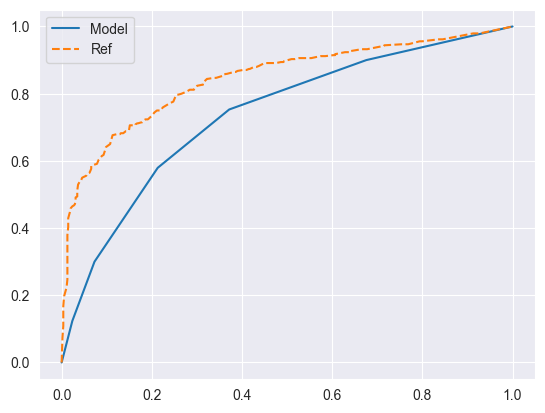

In [74]:
Benchmark_CV(knn,model)

Widzimy ze tutaj modele wyszly bardziej do siebie zbliżone(z lekką przewagą RandomForest)


sprawdźmy sobie jeszcze XGboosta(porównując go do random forest)

Model - F1: 0.7303543913713405 AUC: 0.8390496089146041
Ref - F1: 0.72 AUC: 0.8498285653059038
Model CM:
 [[477  72]
 [103 237]]
Ref CM:
 [[473  76]
 [106 234]]


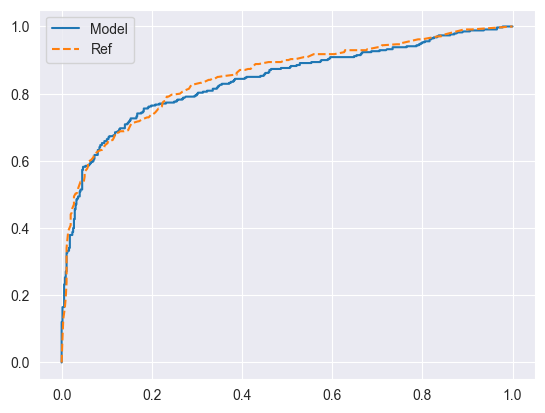

In [75]:
from xgboost import XGBClassifier
XGBC = XGBClassifier()
Benchmark_CV(XGBC,model)

widzimy że XGboost jest lekko gorszy od RandomFotest

Jednak z powodu że różnica jest nieznacznaspróbuje zoptymalizować hiperparametry obu i porównam je jeszcze raz

# Optymalizacja hiperparametrów
Random Forest:
- max depth(3-10)
- min_samples_leaf(1-6)
- min_samples_split(2-10)
- n_estimators(50-300)

XGBoost:
- max depth(2-6)
- learning rate(0.01-0.2)
- subsample(0.6-1)
- colsample bytree(0.6-1)

optymalizujemy pod AUC bo jednak jest trovhe bardziej przewidywalne dzieki temu że używa proba


In [76]:
import optuna
from sklearn.model_selection import cross_val_score

# Wyciszenie logów Optuny, żeby nie zasypywać konsoli
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    # Optymalizujemy średnią wartość AUC z 5-fold CV
    return cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=40)

print("Najlepsze AUC dla Random Forest:", round(study_rf.best_value, 4))
print("Najlepsze parametry RF:", study_rf.best_params)

Najlepsze AUC dla Random Forest: 0.8619
Najlepsze parametry RF: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 1}


In [77]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBClassifier(**params)
    return cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=40)

print("Najlepsze AUC dla XGBoost:", round(study_xgb.best_value, 4))
print("Najlepsze parametry XGBoost:", study_xgb.best_params)

Najlepsze AUC dla XGBoost: 0.8673
Najlepsze parametry XGBoost: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.12406682334217982, 'subsample': 0.7752314059650326, 'colsample_bytree': 0.804294588723857}


dobra to teraz ładujemy hiperparametry do modeli i sprawdzamy
(Główny model to Random forest a referencyjny XGBOOST)


Model - F1: 0.7369942196531792 AUC: 0.8585342333654773
Ref - F1: 0.7346938775510204 AUC: 0.8619414979106398
Model CM:
 [[452  97]
 [ 85 255]]
Ref CM:
 [[486  63]
 [106 234]]


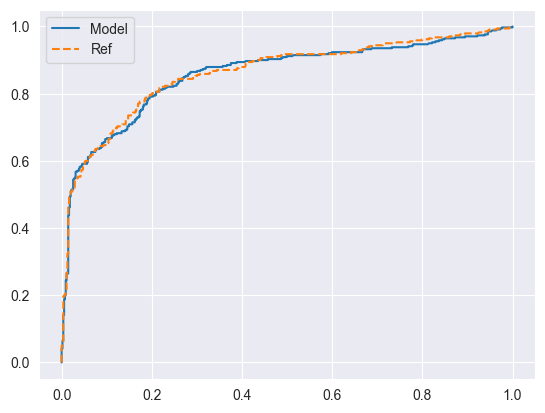

In [78]:
RandomForest = RandomForestClassifier(
    n_estimators=250,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

XGBoost = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.06681354645550217,
    subsample=0.7581139408156309,
    colsample_bytree=0.6260524921860781,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)

Benchmark_CV(RandomForest,XGBoost)

Widzimy że modele znowu wypadły podobnie(jeden ma wiekszy f1 score 2 wieksze AUC)

Tu trzeba odpowiedzieć sobie na pytanie co jest dla nas ważniejsze, ja bym powiedział że ważniejszy jest mimo wszystko AUC gdyż tak jak mówiłem daje nam bardziej pewny wynik.

Z tego też wynika że XGBoost to jest mój najlepszy model z wynikiem
f1: 0.735
AUC: 0.862

Dodatkową zaletą (bądź wadą – w zależności od przyjętego kontekstu biznesowego) jest fakt, że model generuje mniej fałszywych alarmów ($FP$) niż przeoczeń ($FN$). Oznacza to, że rzadziej błędnie prognozuje przeżycie osobie, która w rzeczywistości zginie, niż uznaje za zmarłą osobę, która przeżyje, jeżeli to miałby być klasyfikator według którego mamy wpuścić ludzi na statek to lepiej pogodzić się z tym że na statek nie wejdziemy(pomimo tego że byśmy nie umarli) niż z tym że umrzemy(pomimo tego że model wskazał że przeżyjemy).

# To nie koniec !
Spróbuje jeszcze pobawic sie z feature importances jednak najpierw dodam usunietę przez siebie ccechy z notatnika z zad 1 na podstawie korelacji i spróbuje wytrenować te modele jeszcze raz, a nastepnie wykonac selekcje przez filtrowanie.

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, RobustScaler

path = Path.cwd() / "01_przetwarzanie_wizualizacja_danych" / "titanic.csv"
titanic_df = pd.read_csv(path, index_col='PassengerId')
path = Path.cwd() /  "titanic_cleaned.csv"
titanic_cleaned = pd.read_csv(path, index_col='PassengerId')

# Powrócenie wszystkich usuniętych danych numerycznych
titanic_cleaned["Ticket"] = titanic_df["Ticket"]
TicketSize = titanic_df["Ticket"].value_counts()
titanic_cleaned["TicketSize"] = titanic_df["Ticket"].map(TicketSize)
titanic_cleaned["FamilyAndFriends"] = titanic_df["SibSp"] + titanic_df["Parch"] + titanic_cleaned["TicketSize"]
titanic_cleaned = titanic_cleaned.drop("Ticket", axis=1)
titanic_cleaned["SibSp"] = titanic_df["SibSp"]
titanic_cleaned["Parch"] = titanic_df["Parch"]


X = titanic_cleaned.drop("Survived", axis=1)
y = titanic_cleaned["Survived"]
labels = X.columns

#Zrobie też scalowanie mieszane dla cech z mocnymi odstającymi robust Scaller, dla reszty min max
robust_cols = ['Fare', 'Age']
minmax_cols = [col for col in X.columns if col not in robust_cols]

ct = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), robust_cols),
        ('minmax', MinMaxScaler(), minmax_cols)
    ]
)

X = ct.fit_transform(X)


No i dobra teraz sprawdzamy wykres feature importances dla random forest oraz XGBOOST

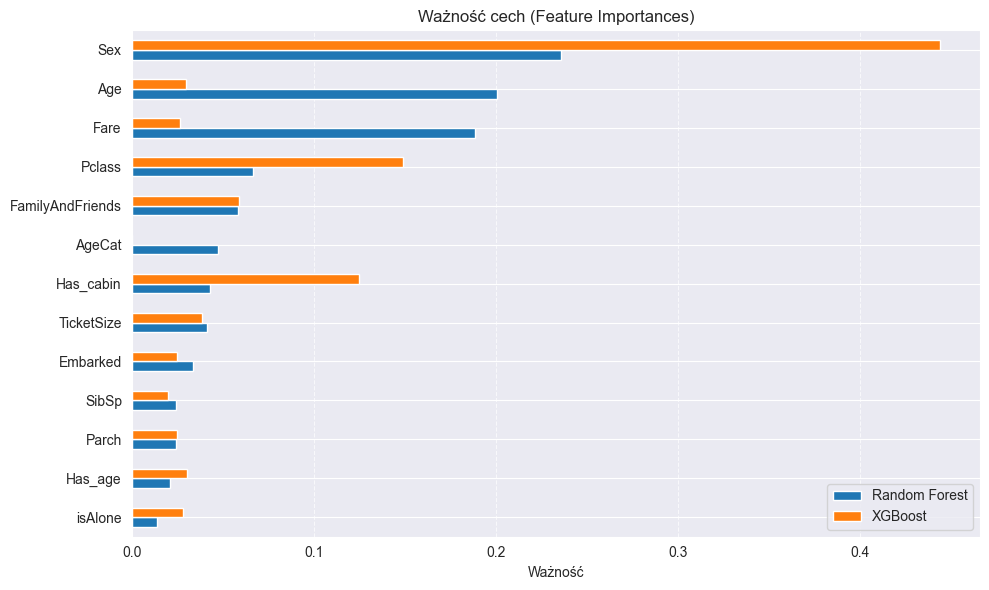

In [80]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Poprawna kolejność nazw kolumn po przeszłym ColumnTransformerze
feature_names = robust_cols + minmax_cols

# Trening modeli
rf = RandomForestClassifier(random_state=42).fit(X, y)
xgb = XGBClassifier(random_state=42, eval_metric="logloss").fit(X, y)

# Zestawienie wyników w DataFrame
df_imp = pd.DataFrame(
    {"Random Forest": rf.feature_importances_, "XGBoost": xgb.feature_importances_},
    index=feature_names,
).sort_values(by="Random Forest", ascending=True)

# Plotowanie
df_imp.plot(kind="barh", figsize=(10, 6))
plt.title("Ważność cech (Feature Importances)")
plt.xlabel("Ważność")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Szok !
Okazuje się że kolumna isAlone jest najmniej ważna ze wszytskich cech
Widzę również że warto usunąć:
- Has_age
- Parch
- SibSp

In [81]:
titanic_cleaned = titanic_cleaned.drop(["isAlone","Has_age","Parch","SibSp"], axis=1)

powtarzamy teraz proces dobrania hiperparametrów dla RandomForest oraz XGBOOST.
Powtarzamy również benchmark porównujący oba te modele

In [82]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=40)

print("Najlepsze AUC dla Random Forest:", round(study_rf.best_value, 4))
print("Najlepsze parametry RF:", study_rf.best_params)
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=40)

print("Najlepsze AUC dla XGBoost:", round(study_xgb.best_value, 4))
print("Najlepsze parametry XGBoost:", study_xgb.best_params)

Najlepsze AUC dla Random Forest: 0.8697
Najlepsze parametry RF: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 5}
Najlepsze AUC dla XGBoost: 0.8754
Najlepsze parametry XGBoost: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.16114477000088795, 'subsample': 0.8546770641476331, 'colsample_bytree': 0.791698401393067}


Model - F1: 0.7360912981455064 AUC: 0.8567689917497053
Ref - F1: 0.7223113964686998 AUC: 0.8598066002357228
Model CM:
 [[446 103]
 [ 82 258]]
Ref CM:
 [[491  58]
 [115 225]]


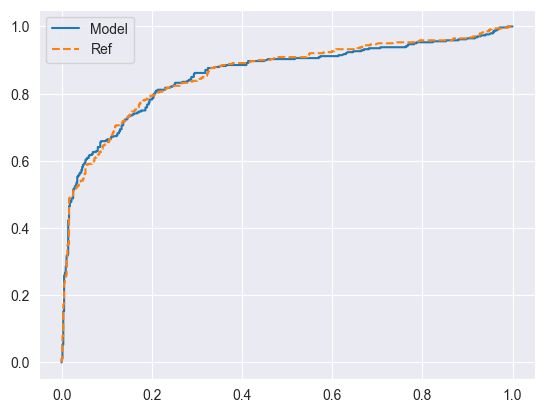

In [83]:
RandomForest = RandomForestClassifier(
    n_estimators=50,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

XGBoost = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate = 0.044352213075783825,
    subsample=0.7687489897935941,
    colsample_bytree=0.9263984920397917,
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)
Benchmark_CV(RandomForest,XGBoost)

No niestety modele działają ale gorzej niż się spodziewałem.

Ciężko mi powiedzieć który model jest jeddnoznacznie lepszy bo liczby wskazują na Random forest, jednak z kontekstu biznesowego mogłoby okazać się że lepszy jest ten z XGBoosta

## Poprawa Data leakage
Najpierw robiłem tak że najpierw skalowałem i dzieliłem dane i teraz zrobiłem tak że najpierw dziele i potem skaluje.

Skutkiem tego jest to że cały zbiór X nie jest przeskalowany więc przy robieniu cross validacji pracuje na nieprzeskalowanych danych. Ale ostateczny wynik się nie różni, dlaczego??

Bo wybrałem modele które są oparte na drzewach decyzyjnych co wiąże się z tym że nie ma dla nich różnicy czy zbiór jest przeskalowany czy nie.

Jeżeli wybrałbym model dla którego przeskalowanie ma znaczenie, musiałbym bawić sie w pipeline, ale z racji że wybrałem co wybrałem nie musze tego robić.